# Feature engineering et Feast Store

La pratique du Machine Learning montre que, quelle que soit la puissance des modèles, des données mal préparées limitent fortement leurs performances. Le paradigme data-centric s’impose ainsi face à l’approche model-centric. Il souligne le rôle central du feature engineering. 

Contrairement à l’ETL, celui-ci consiste en des transformations statistiques visant à aligner les données avec les hypothèses des modèles. 

Si l’expérimentation du Machine Learning n’a pas les mêmes données que la production et donc le modèle utilisé par l’utilisateur, les résultats de l’expérimentation sont donc nécessairement trompeurs. On aura sûrement le problème de “Training serving skew”. 

Pour éviter ce problème, après le feature engineering, nous devons stocker dans un Feature store les features modifiés et prêts pour le Machine Learning. Le Feature Store doit alimenter non seulement la phase de prototyping mais aussi la production. Il ne passe pas directement dans le modèle servant l’interface client. Il passe d’abord en Stagging. 

# 1_Check_FEAST

L'objectif de ce fichier est de vérifier la structure de FEAST dans un fichier Jupyter Notebook pour voir comment on pourrait y importer les données.  

Résultat : Dataset constructible depuis FEAST.

# 2_Stationarity

**Objectif**

Dans ce fichier, notre objectif est de rendre nos données stationnaires. Ainsi, nous avons suivi les étapes suivantes : 

**Démarche**

1) Analyse graphique de la stationnarité
2) identification de l'origine de la non-stationnarité
3) Rendre les séries temporelles stationnaires
4) Analyse de l'auto-corrélation
5) Analyse de la volatilité des variables explicatives
6) Différenciation de second ordre
7) Combinaison des données stationnaires
8) Combiner les indicateurs de récession aux données stationnaires
9) Graphiques des variables originales et stationnaires côte à côte
10) Exporter la série stationnaire

**Conclusion**

La conclusion de ce fichier est que que : 
- Le target, le taux de chômage (UNRATE) est déjà stationnaire. Il a été différencié toutefois puisqu'on voulait expliquer le taux de croissance du chômage dans ce projet.
- Voici les variables assurément stationnaires avec l'ordre 1 : 
    - INDPRO :activité industrielle 
    - RPI : revenu personnel réel des ménages
    - S&P 500 : indice boursier représentatif du marché actions américain
    - DPCERA3M086SBEA : dépenses de consommation réelles.
    - TB3MS : taux d’intérêt à court terme
- Pour avoir une explication de chaque variable en termes de croissance, le TB3MS (un taux) a été différencié en point contrairement aux autres avec un log.
- A cause d'une mémoire longue présente dans les variables suivantes ou exceptionnellement pour sa volatilité (OILPRICEx), une seconde différenciation a été nécessaire : 
    - BUSLOANS : prêts bancaires aux entreprises
    - CPIAUCLS : indice des prix à la consommation (inflation)
    - M2SL : masse monétaire au sens large
    - OILPRICEx : prix du baril de pétrole
- USREC indique la présence d'une période de récision ou non

**Next action :** 
splitter les données TRAIN-TEST

# Data Analysis et expérimentation

Une fois que le pré-traitement et le FEAST ont été effectué, on passe au Data Analysis et l'expérimentation. Ce pair de brique forme un petit système dans le grand système de l'IA. Partons de l'expérimentation pour mieux expliquer leur interdépendance. 

Durant la phase de l’expérimentation, un data scientist veut tester tous les modèles possibles dans le sujet notamment les modèles les plus sophistiqués et lourds et le Deep Learning.  Ce paradigme de Model-Centric a été déjà dépassé à partir du feature engineering. Même sans vouloir tester les modèles de dernière génération, un autre piège pourrait sortir ici.

Sans une direction claire, cette phase peut devenir très vite fastidieuse et ne s’arrête jamais. C'est une des raisons pour laquelle une entreprise s'arrête à la phase de prototype.   

La principale question ici est de savoir quand est-ce qu’on a un modèle de Machine Learning suffisant ? Définir le modèle suffisant peut très vite laisser à des confusions. Puisqu’il peut y a avoir à ce niveau plusieurs objectifs (parfois conflictuels) plausibles : 
- Maximiser la performance ↔ Préserver l’explicabilité 
- Renforcer la robustesse face au bruit et aux anomalies ↔ Maintenir une précision élevée sur des données propres 
- Réduire la complexité du modèle ↔ Capturer des relations riches et fortement interactionnelles 
- Limiter les coûts de calcul et les temps d’inférence ↔ Maximiser la performance via des modèles lourds 
- Garantir la reproductibilité des résultats ↔ Utiliser des méthodes stochastiques ou adaptatives 
- Respecter les contraintes réglementaires et éthiques ↔ Exploiter l’ensemble des données disponibles 
...   

L’essentiel est de comprendre à priori la direction de l’expérimentation.

Pour ce faire, un schéma itératif bien cadré se pose pour bien choisir le modèle et ne pas se disperser

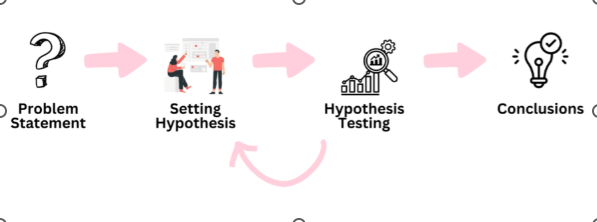

C'est ici que le Data Analysis entre en jeu. Dans un système dashbord, le Data Analysis oriente quel graphique ou chiffre clé à faire parler. Analogiquement, dans le système IA, il permet de formuler précisémment les problèmes et émettre des hypothèses à vérifier dans la phase de l'expérimentation du Machine Learning.

Le Data Analysis prend tout son ampleur surtout dans un système d'IA explicable. Il permet non seulement de justifier le choix d'une expérimentation (d'un modèle) mais aussi justifier en quoi un modèle a été choisi. 

Dans cette situation, on ne parle plus de Dashbord mais de leadbording. Le Leadbording est le Dashbord de l'IA explainable. 

A titre de perpsective, c'est à travers lui que toutes personnes s'intéressent à notre système d'IA interragit directement dans la phase de décision. 

D'ailleurs, le Gen AI dans le support décisionnel restitue un rapport sur le leaderbord. 

C'est pour dire que la phase du Data analysis-Expérimentation est centrale dans notre architecture. 

# 3_univariate_analysis

# 3_1_Autocorrelation Analysis

Le Time Series se définit comme une donnée capable d'apprendre par son passé pour prévoir le futur. C'est le forecasting.

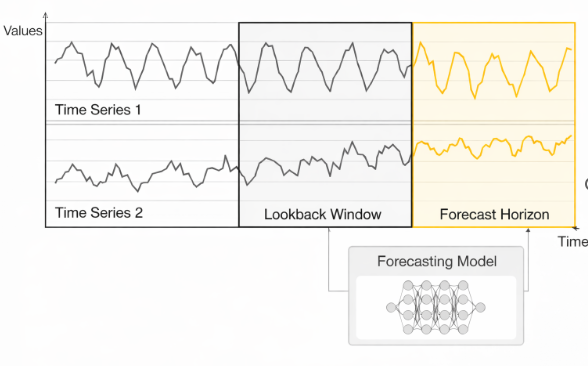

Cette définition n'est nécessairement vérifié cependant surtout pour une donnée temporelle économique qui change souvent dans le temps. 

Il faut donc vérifier la pertinence de cette hypothèse via plusieurs questions. 

## H1 : Le taux de croissance du chômage peut être expliqué par ses passées. 

Pour répondre à l'hypothèse, on répond à plusieurs questions. 

### Q1 : Quelles valeurs passées du chômage expliquent-elles ses valeurs présentes ?

3_univariate_analysis : 
- le mois dernier explique fortement la croissance du taux de chômage présent.
- Celui de l'année dernier aussi mais moins évident.  

### Q2 : Dans quelles mesures les valeurs passées du mois derniers sont efficaces pour mieux expliquer le chômage actuel?  

Experiment 6_1 :
- la croissance du chômage d'un mois passé permet de prévoir celle du mois à venir dans la période de stabilité macroéconomique (avant 2008)
- A partir de la crise de 2008, le modèle autorégressif fournit moins de certitude notamment à partir de la crise de Covid-19.  

### Q3 : Jusqu'où l'optimisation de la valeur du nombre de retards permet-il d'améliorer les résultats de AR1 ? 

Experiment 6_2 : 
- ...
- ...

Réponse finale :
- L'hypothèse de d'auto-corrélation modélisable est partiellement satisfaisante ;
- L'économie connait donc des chocs, des facteurs externes qui entrent dans la prévision notamment dans les moments de crises.

## 3_2 Crisis Analysis

H2 : L’autocorrélation étant insuffisante, les variables exogènes deviennent nécessaires pour capturer les chocs économiques et améliorer la prévision.

Q1 : Quelles sont les principales crises dans l'économie américaine après 1960? 

3_univariate_analysis

En termes de durrée, les trois crises les plus persistantes Etats-Unis après 1960 sont : 
- les deux premiers chocs pétroliers (70s et 80s) ; 
- La crise de 2008 et de 2020. 

Q2 : La croissance du taux de chômage est-t-il liée à l'indicateur de crises de l'économie américaine ?  

4_bivariate_exploration

- La récession ou la crise économique des Etats-Unis devancent toujours une hausse de chômage. 
- La phase de relance résorbe le chômage.  

Q3 : Quelles sont donc les variables qui ont marqué la crise économique des Etats-Unis? 

3_univariate_analysis et 4_bivariate_analysis : 
- Le prix du Baril de Pétrol (OILPRICEX) marque les deux grandes crises pétrolières ; 
- Le crédit bancaire aux entreprises (BUSLOANS) a été au centre de la crise pétrolière ; 


La crise de pétrole signifie baisse drastique du cours du pétrol. Nous devrons donc tenir en compte du prix du baril du pétrol dans nos modèles. Il capte les chocs centraux globaux. Si le chômage est liée à l'indicateur de récession (voir analyse bivariée).

La crise des subprimes correspond à une rupture du canal du crédit. La dégradation des prêts a provoqué un credit crunch. Normalement, celà freine l’investissement et la consommation. Cet effet multiplicateur entraine la persistance de la dégradation de la performance économique. 

Le BUSLOANS est donc une variable très important dans nos expérimentations. 

Les trois grandes crises de l'économie américaine après 1960 sont 